# 01 — Exploratory Data Analysis: EPL Penalties

**Dataset:** 6 EPL seasons of penalty kicks (628 rows after cleaning).

This notebook covers:
1. Loading + cleaning the raw spreadsheet.
2. Class balance (Scored vs Missed) and corner distribution.
3. Numeric feature distributions.
4. Categorical feature breakdowns.
5. Correlation heatmap.

All figures are written to `report/figures/` for the report and slides.

In [1]:
import sys
from pathlib import Path
ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', context='talk')

from src.data import build_dataset, load_processed, ANGLE_ORDER

FIG_DIR = ROOT / 'report' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

## 1. Load + clean

In [2]:
info = build_dataset(ROOT / 'data/raw/Epl Penalties.xlsx', ROOT / 'data/processed')
print('Built dataset:', info)
df, shooters, gks = load_processed(ROOT / 'data/processed')
df.head()

Built dataset: {'parquet': WindowsPath('D:/CUFE/Eightth term/Machine Learning/Project/epl-penalty-ml/data/processed/penalties.parquet'), 'shooters': WindowsPath('D:/CUFE/Eightth term/Machine Learning/Project/epl-penalty-ml/data/processed/shooters.csv'), 'gks': WindowsPath('D:/CUFE/Eightth term/Machine Learning/Project/epl-penalty-ml/data/processed/gks.csv'), 'n_rows': 628, 'n_players': 138, 'n_gks': 73, 'n_teams': 28}


,Player,Nationality,Foot,Outcome,Venue,Minute,Condition,GK,Gameweek,Season,Team,GK_Height,Angle,Continent,TeamCategory,Scored,ShooterConvRate,GKSaveRate
0,Joe Ralls,England,Left-Footed,Missed,Away,35.0,Drawing,Lukasz Fabianski,15.0,18/19,Cardiff City,1.90,Right Bottom,Europe,Small,0,0.816879,0.346154
1,Romelu Lukaku,Belgium,Left-Footed,Scored,Home,56.0,Winning,Sá,36.0,21/22,Chelsea,1.92,Left Bottom,Europe,Big Six,1,0.816879,0.136364
2,Aaron Mooy,Australia,Right-Footed,Scored,Home,52.0,Losing,Kasper Schmeichel,33.0,18/19,Huddersfield Town,1.89,Middle Bottom,Asia,Small,1,0.816879,0.148148
3,Aboubakar Kamara,Mauritania,Right-Footed,Missed,Home,82.0,Drawing,Jonas Lössl,20.0,18/19,Fulham,1.95,Right Bottom,Africa,Average,0,1.000000,0.000000
4,Aboubakar Kamara,Mauritania,Right-Footed,Scored,Away,67.0,Losing,David de Gea,16.0,18/19,Fulham,1.92,Right Bottom,Africa,Average,1,0.000000,0.181818


## 2. Class balance

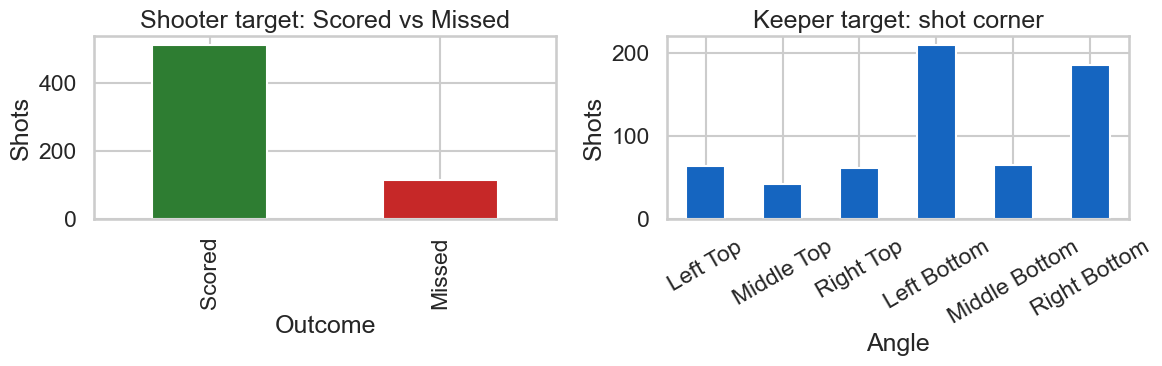

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['Outcome'].value_counts().plot(kind='bar', color=['#2E7D32', '#C62828'], ax=axes[0])
axes[0].set_title('Shooter target: Scored vs Missed'); axes[0].set_ylabel('Shots')

df['Angle'].value_counts().loc[ANGLE_ORDER].plot(kind='bar', color='#1565C0', ax=axes[1])
axes[1].set_title('Keeper target: shot corner'); axes[1].set_ylabel('Shots')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
fig.savefig(FIG_DIR / 'eda_class_balance.png', dpi=150)
plt.show()

**Observations:**
- Scored vs Missed is ~82/18 — heavily imbalanced. We handle this with `class_weight='balanced'` for LogReg/SVM and SMOTE for MLP.
- The 6 corner classes are mildly imbalanced — Left/Right Bottom dominate. We use SMOTE during training for all keeper models.

## 3. Numeric features

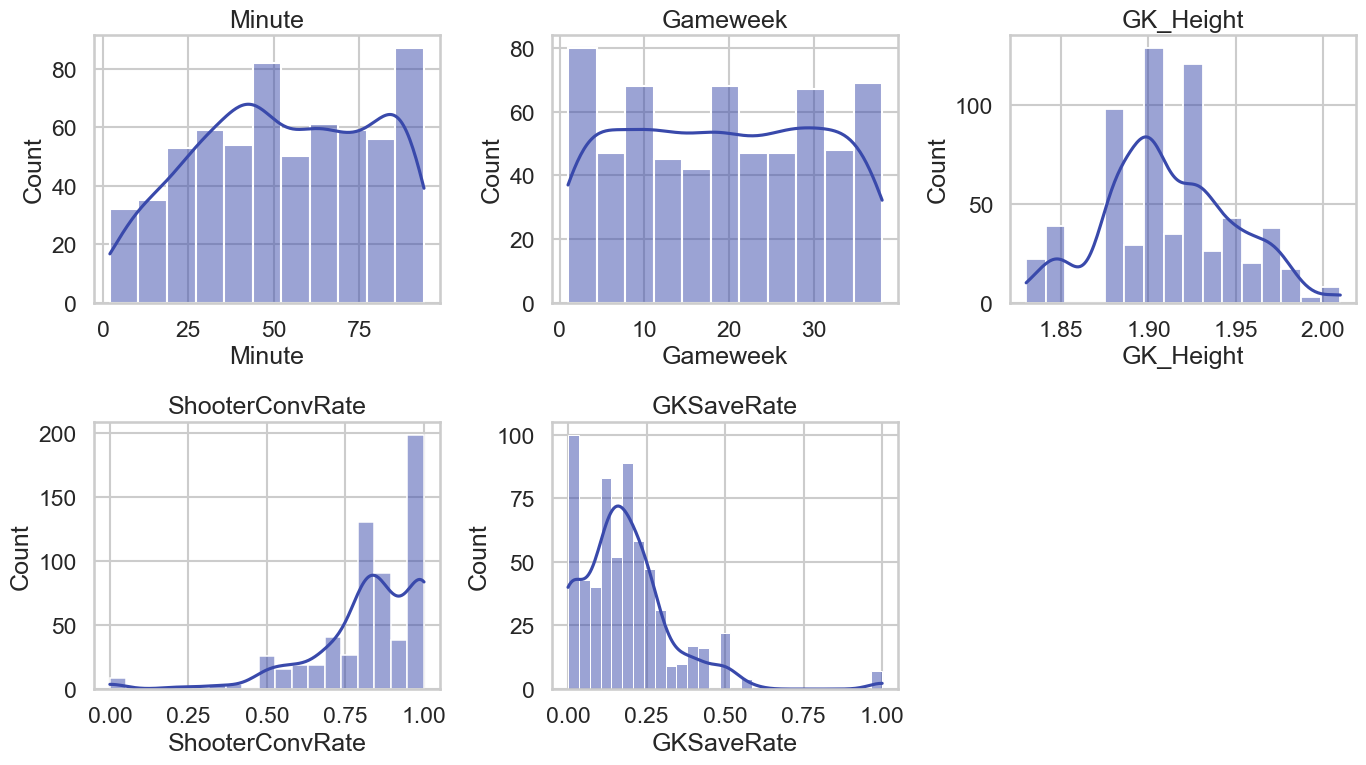

In [4]:
num_cols = ['Minute', 'Gameweek', 'GK_Height', 'ShooterConvRate', 'GKSaveRate']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, c in zip(axes.flat, num_cols):
    sns.histplot(df[c], kde=True, ax=ax, color='#3949AB')
    ax.set_title(c)
axes.flat[-1].axis('off')
plt.tight_layout()
fig.savefig(FIG_DIR / 'eda_numeric_dists.png', dpi=150)
plt.show()

## 4. Categorical breakdowns

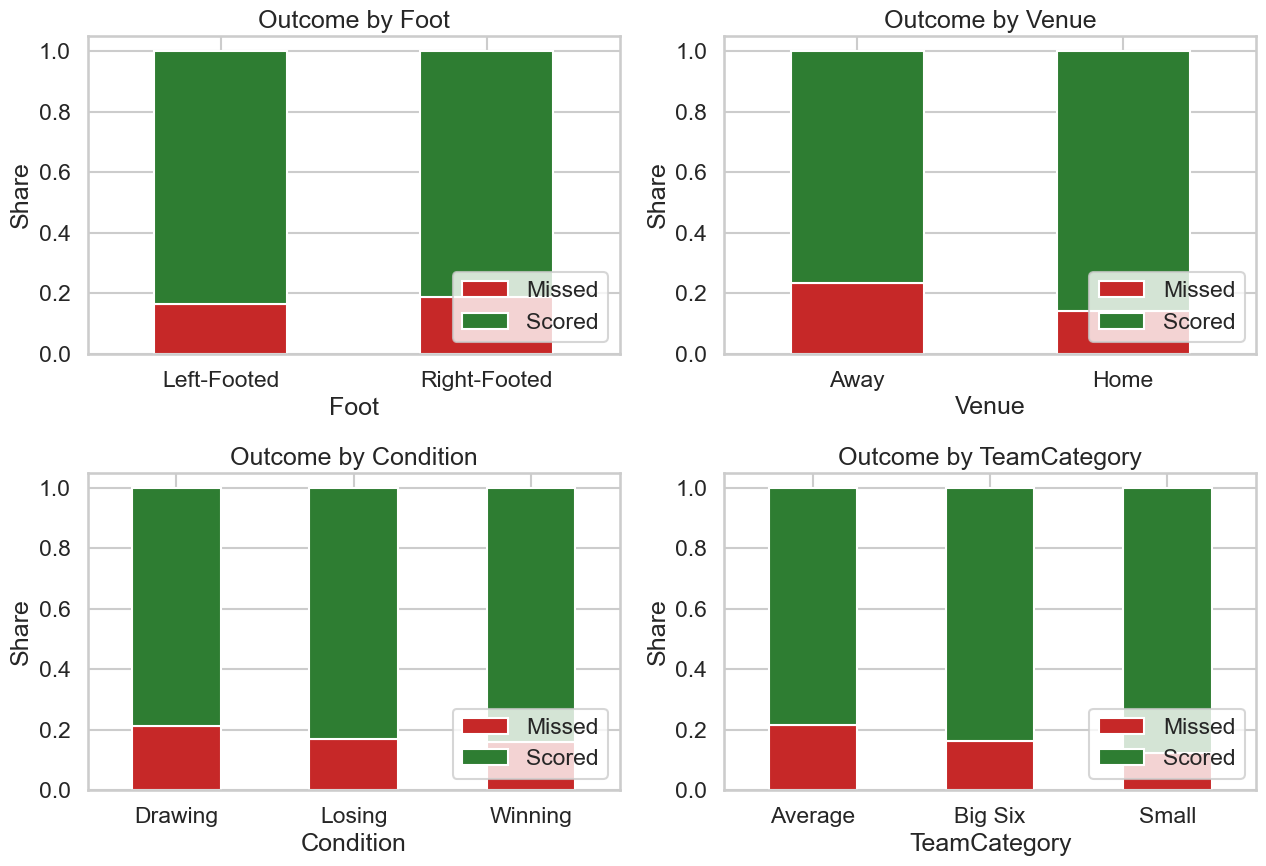

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, c in zip(axes.flat, ['Foot', 'Venue', 'Condition', 'TeamCategory']):
    ct = pd.crosstab(df[c], df['Outcome'], normalize='index')
    ct.plot(kind='bar', stacked=True, ax=ax,
            color={'Scored': '#2E7D32', 'Missed': '#C62828'})
    ax.set_title(f'Outcome by {c}'); ax.set_ylabel('Share'); ax.legend(loc='lower right')
    ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
fig.savefig(FIG_DIR / 'eda_outcome_by_categorical.png', dpi=150)
plt.show()

## 5. Correlation heatmap

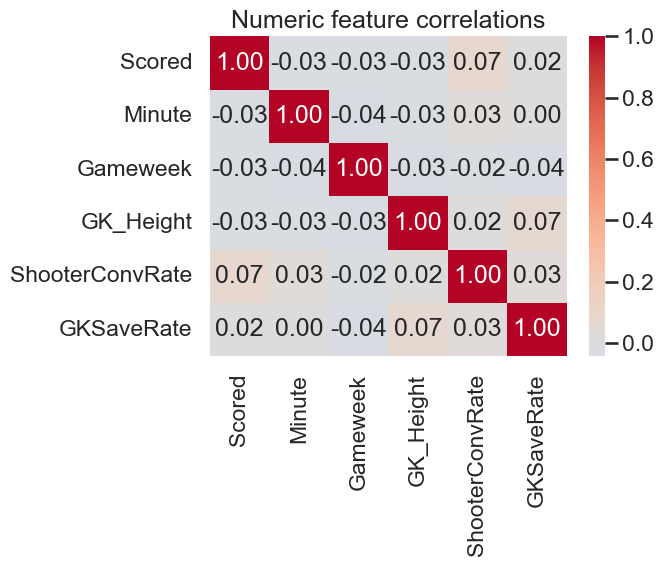

In [6]:
corr_cols = ['Scored', 'Minute', 'Gameweek', 'GK_Height',
             'ShooterConvRate', 'GKSaveRate']
corr = df[corr_cols].corr()
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Numeric feature correlations')
plt.tight_layout()
fig.savefig(FIG_DIR / 'eda_correlation.png', dpi=150)
plt.show()

## Takeaways for modeling
- **Highly imbalanced target** for the shooter task — accuracy alone is misleading; use ROC-AUC.
- **Numeric features have weak linear correlation** with the target — non-linear models (SVM-RBF, MLP) may help, though dataset size limits their advantage.
- **Shooter conversion rate and GK save rate** are the strongest individual predictors as expected.
- **Categorical features matter**: foot, venue, team category and condition all shift the score rate.